In [1]:
# !pip install opencv-python
# !pip install pandas
# !pip install matplotlib
# !pip install urllib
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/internationaal/thinktank/fotos-en-logos/ku-leuven-logo.png/image_preview" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [3]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    './kul-computer-vision-ga-1-2026/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    './kul-computer-vision-ga-1-2026/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('./kul-computer-vision-ga-1-2026/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('./kul-computer-vision-ga-1-2026/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [4]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [5]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [6]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [7]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return None
        if len(faces) == 0:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation = cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)

**Visualise**

Let's plot a few examples.

In [8]:
# parameter to play with 
FACE_SIZE = (100, 100)

def plot_image_sequence(data, n, imgs_per_row=7, plot_gray = False):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            if(plot_gray):
                ax.imshow(data[i], cmap = 'gray')
            else:
                ax.imshow(data[i])
        elif n_rows > 1:
            if(plot_gray):
                ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i], cmap = 'gray')
            else:
                ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

    
#preprocessed data 
preprocessor = HAARPreprocessor(path = '../../tmp', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)



C:\Users\sahil\AppData\Local\Temp\ipykernel_36748\4005177570.py:53: RuntimeWarning: invalid value encountered in cast
  return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)


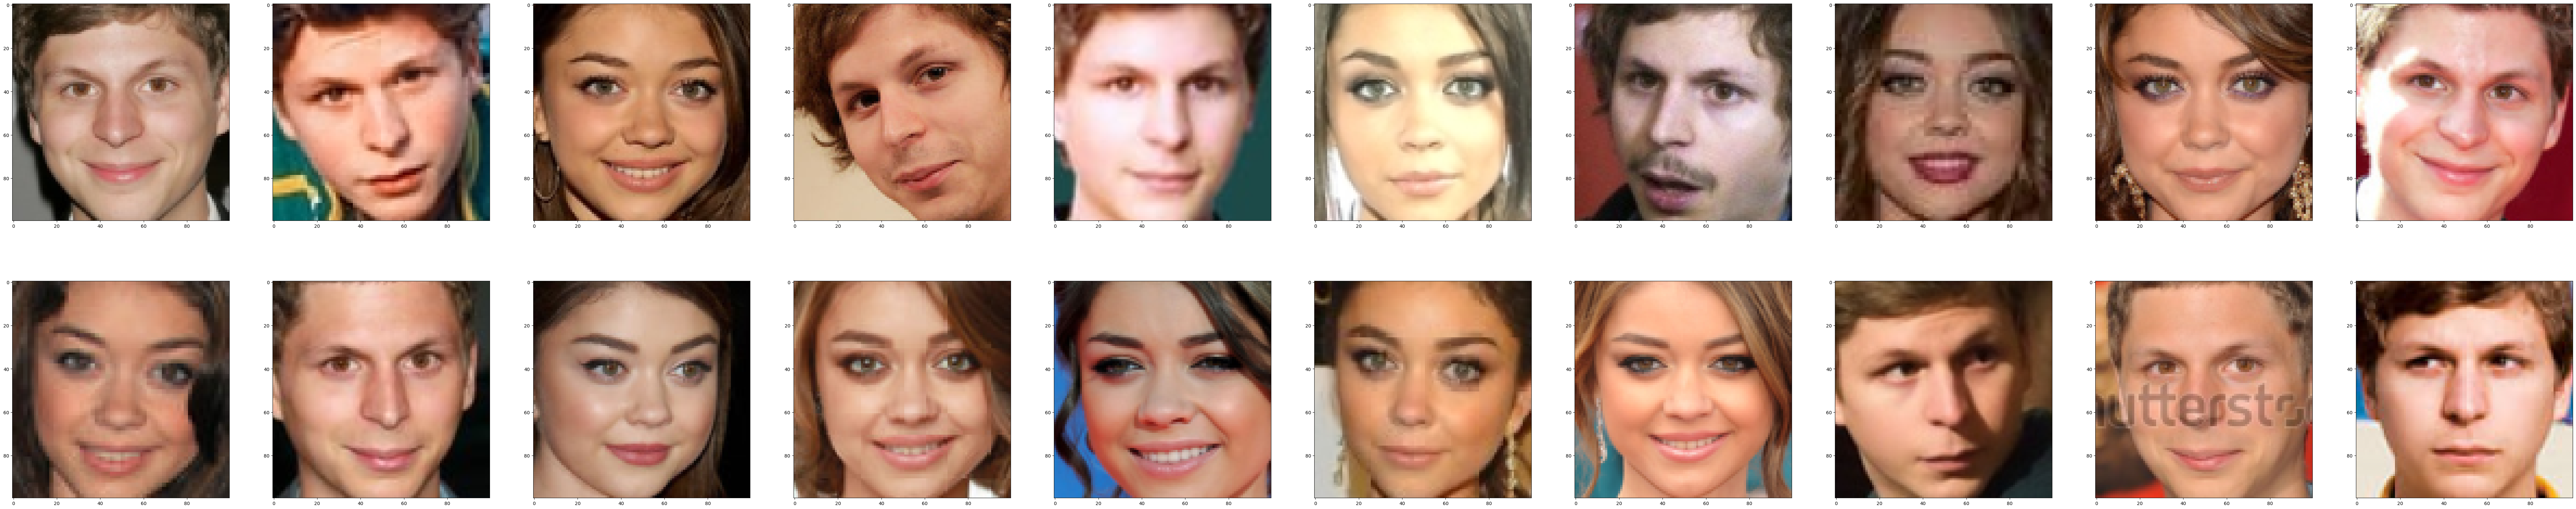

In [9]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].


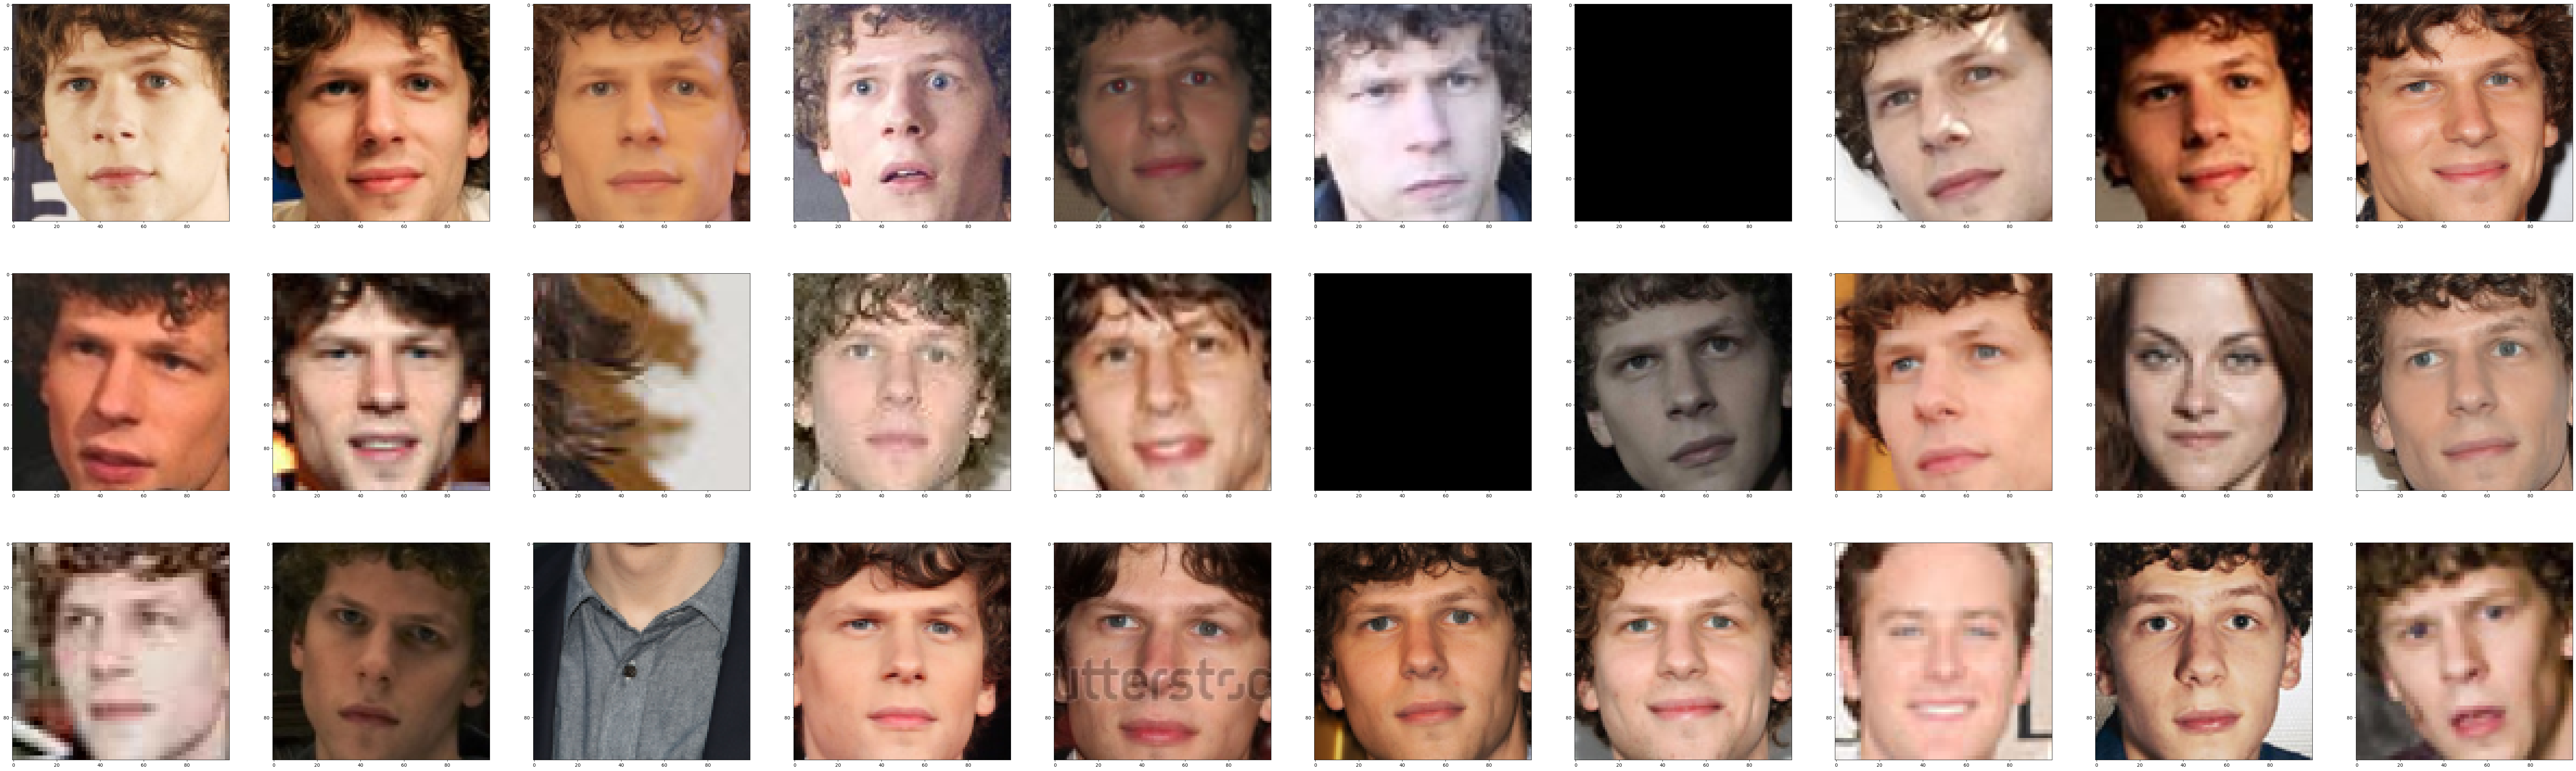

In [10]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9223372036854775808..-9223372036854775808].


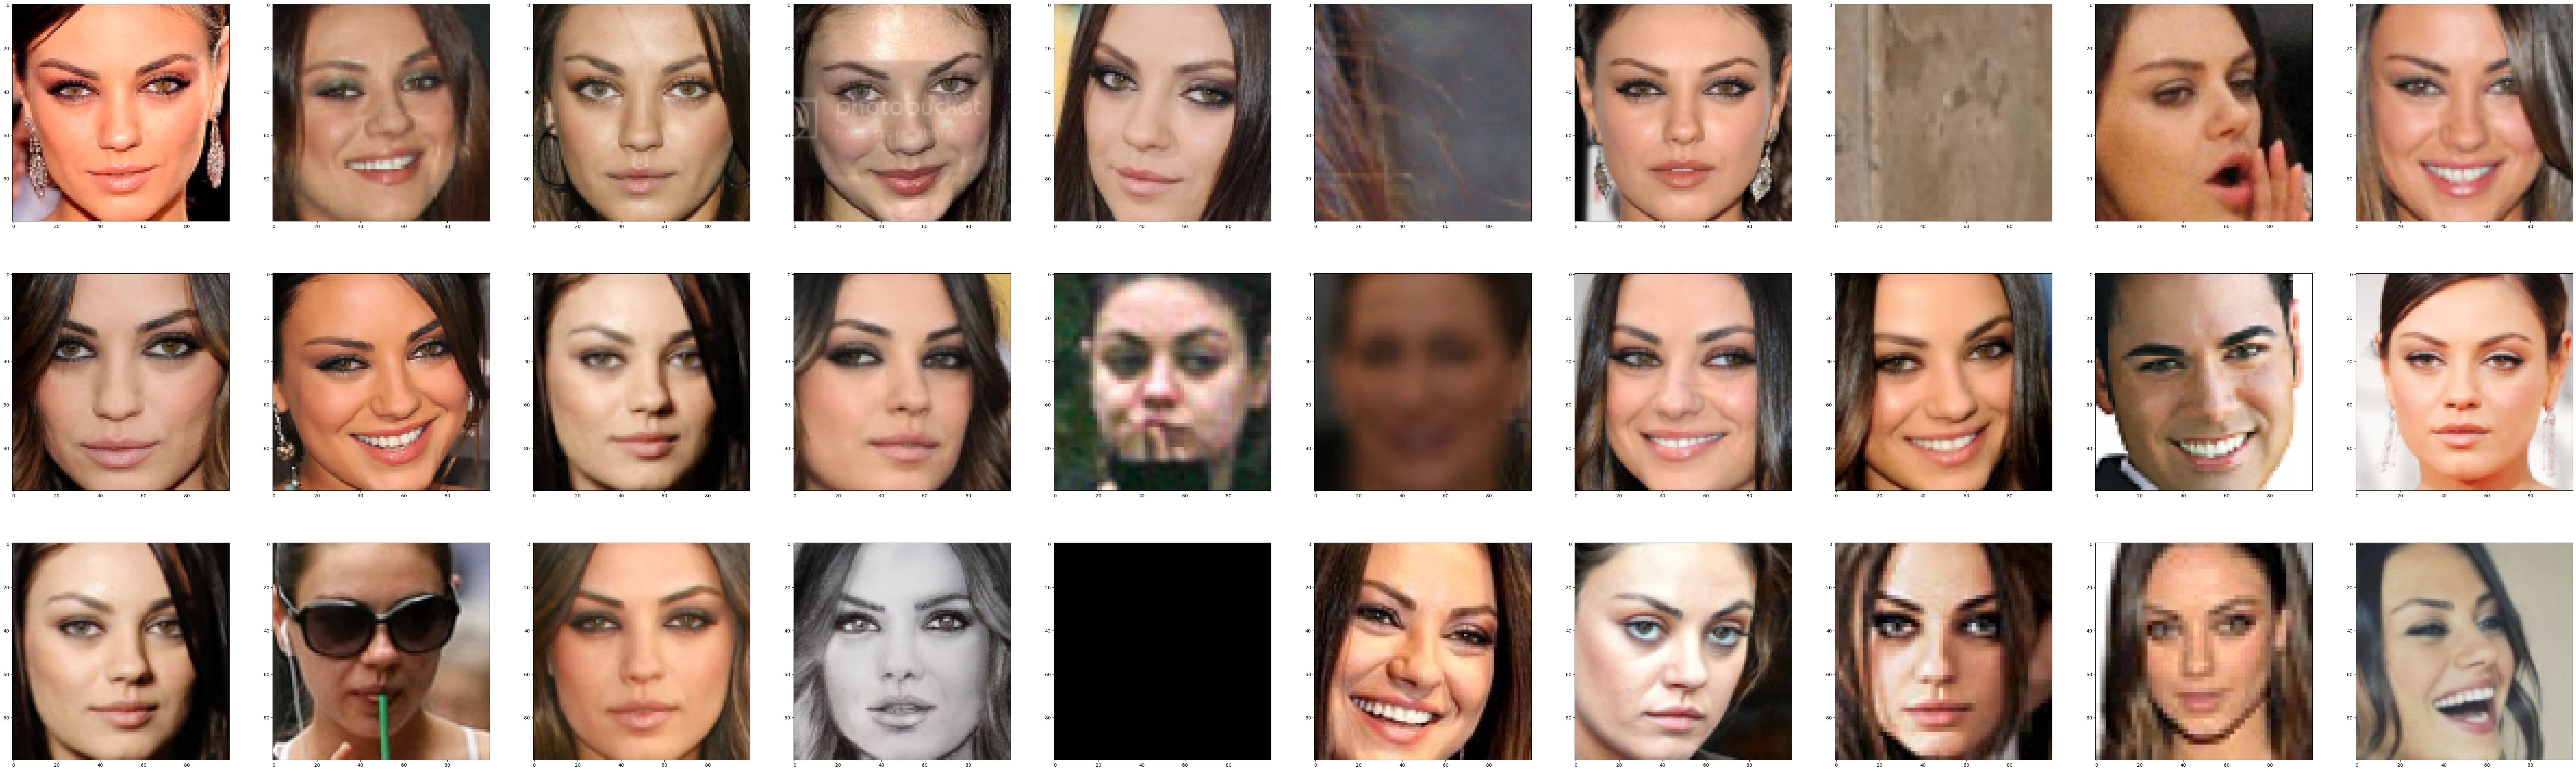

In [11]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [12]:
# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [13]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [14]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(**params):
        self.params = params
        
    def transform(self, X):
        raise NotImplmentedError

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [15]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    def __init__(self, n_components=None):
        self.n_components = n_components          # Number of selected feature vectors
        self.mean_ = None                         # Mean of the training dataset
        self.components_ = None                   # Selected feature vectors
        self.explained_variance_ = None           # How much variance is covered by the selected feature vectors
        self.explained_variance_ratio_ = None     # Ratio of variances explained by each principal component
        self.singular_values_ = None              # Eigen values for corresponding principal vectors(feature vectors)
        self.image_shape_ = None                  # Shape of the image
        self.n_features_ = None                   # Total feature vectors possible
        self.n_samples_ = None                    # Training sample size
        self.is_fitted_ = False                   # If the model is trained or not\self.
        self.is_use_RGB_ = False

    # Convert the image to grayscale to obtain a 2D matrix
    # N   = Number of images
    # H,W = Shape of images
    # C   = channels(3-color & 1-gray)
    def _to_gray(self, X):
        X = np.asarray(X, dtype=np.uint8)

        if X.ndim == 4:
            # X: (N, H, W, C)
            X_gray = np.array([
                cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in X
            ], dtype=np.float32)
        elif X.ndim == 3:
            # already grayscale: (N, H, W)
            X_gray = X
        else:
            raise ValueError("X must have shape (N, H, W) or (N, H, W, C)")

        return X_gray

    # Flatten the dataset, output shape: (N, H*W)
    def _flatten(self, X):
        if(not self.is_use_RGB_):
            X_processed = self._to_gray(X)
            X_processed = X_processed.reshape(X.shape[0], -1)
        else:
            R = X[:, :, :, 0].reshape(X.shape[0], -1)
            G = X[:, :, :, 1].reshape(X.shape[0], -1)
            B = X[:, :, :, 2].reshape(X.shape[0], -1)

            X_flat = np.concatenate([R, B, G], axis=1)
            X_processed = np.asarray(X_flat, dtype=np.uint8)
        return X_processed

    # Compute the principal components from the training dataset X.
    def fit(self, X, comp_mean = True, use_RGB = False):
        
        self.is_use_RGB_ = use_RGB
        if(use_RGB):
            R = X[:, :, :, 0].reshape(X.shape[0], -1)
            G = X[:, :, :, 1].reshape(X.shape[0], -1)
            B = X[:, :, :, 2].reshape(X.shape[0], -1)

            X_flat = np.concatenate([R, B, G], axis=1)
            X_processed = np.asarray(X_flat, dtype=np.uint8)
        else:
            X_processed = self._to_gray(X)

        self.image_shape_ = X_processed.shape[1:]   # (H, W)

        X_flat = X_processed.reshape(X_processed.shape[0], -1)   # (N, D)
        self.n_samples_, self.n_features_ = X_flat.shape

        # Compute and substract the mean of the training data as PCA is supposed to find directions of variations, 
        # which gets influenced by the mean. So, without this step, the covariance is not computed correctly which leads to the
        # first component being the dominated by the mean and less meaningful eigen faces.
        if(comp_mean):
            self.mean_ = X_flat.mean(axis=0, keepdims=True)
        else:
            self.mean_ = 0
        
        X_centered = X_flat - self.mean_

        # Advantages of using SVD over EVD are:
        # 1. Numerical stabality as we don't have to build a covariance matrix.
        # 2. Works better with low rank dataset, as in images there is a lot of correlation between different inputs the covariance 
        #    matrix could become low rank.
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

        max_rank = min(self.n_samples_ - 1, self.n_features_)
        if self.n_components is None:
            k = max_rank
        else:
            k = min(self.n_components, max_rank)

        # Gather all the compoments
        self.components_ = Vt[:k]   # (k, D)
        self.singular_values_ = S[:k]

        # Compute the variances explained by each principal component
        if self.n_samples_ > 1:
            all_explained_variance = (S ** 2) / (self.n_samples_ - 1)
        else:
            all_explained_variance = np.zeros_like(S)

        self.explained_variance_ = all_explained_variance[:k]

        # Ratio of variances explained by each principal component
        # Could be used to select the right number of components used
        total_var = np.sum(all_explained_variance)
        if total_var > 0:
            self.explained_variance_ratio_ = self.explained_variance_ / total_var
        else:
            self.explained_variance_ratio_ = np.zeros_like(self.explained_variance_)

        # Just a safety mechanism to ensure the PCA components are extracted before anything else is done.
        self.is_fitted_ = True

        return self

    # Prject other images onto the learnt subspace
    def transform(self, X):
        if not self.is_fitted_:
            raise ValueError("Call fit() before transform().")

        X_flat = self._flatten(X)
        X_centered = X_flat - self.mean_
        return X_centered @ self.components_.T

    # Use the eigen faces to reconstruct the target face.
    def reconstruct_with_k(self, X, k):
        if not self.is_fitted_:
            raise ValueError("Call fit() before reconstruct_with_k().")

        X_flat = self._flatten(X)
        X_centered = X_flat - self.mean_

        k = min(k, self.components_.shape[0])
        Zk = X_centered @ self.components_[:k].T         # Projection to the subspace using only selected principal components
        X_recon = Zk @ self.components_[:k] + self.mean_ # Reconstruct back the main face.
        return X_recon.reshape((X.shape[0],) + self.image_shape_)

    # Function to choose the right amount of components by considering how much variance should be accounted for.
    def choose_p_by_variance(self, threshold=0.95):
        cumulative = np.cumsum(self.explained_variance_ratio_)
        p = np.searchsorted(cumulative, threshold) + 1
        return p, cumulative

    ############################################################# Helper functions for plotting ###########################################################
    # Discalimer: The below functions were created using chatGPT with minor modifications from us.
    def show_reconstruction_progression(self, X, image_index=0, ks=[1, 5, 10, 20, 50]):
        original = X[image_index:image_index+1]

        ncols = len(ks) + 1
        plt.figure(figsize=(3*ncols, 3))

        # original
        plt.subplot(1, ncols, 1)
        img = original[0]
        if img.ndim == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(np.clip(img, 0, 255))
        plt.title("Original")
        plt.axis("off")

        for i, k in enumerate(ks, start=2):
            recon = self.reconstruct_with_k(original, k)[0]
            plt.subplot(1, ncols, i)
            if recon.ndim == 1:
                recon_img = self.vec_to_rgb_image(recon)
                recon_img = np.clip(recon_img, 0, 255).astype(np.uint8)
                plt.imshow(recon_img)
            elif recon.ndim == 2:
                plt.imshow(recon, cmap='gray')
            else:
                plt.imshow(np.clip(recon, 0, 255).astype(np.uint8))
            plt.axis("off")

        plt.tight_layout()
        plt.show()
    
    def vec_to_rgb_image(self, vec, Height=100, Width=100):
        D = Height * Width

        r = vec[0:D].reshape(Height, Width)
        b = vec[D:2*D].reshape(Height, Width)
        g = vec[2*D:3*D].reshape(Height, Width)

        img = np.stack([r, g, b], axis=-1)   # back to RGB
        return img

    def plot_pca_2d_with_extractor(self, X, y, label_names=None):
        if not self.is_fitted_:
            raise ValueError("Fit the PCAFeatureExtractor before plotting.")

        Z = self.transform(X)

        if Z.shape[1] < 2:
            raise ValueError("PCAFeatureExtractor must have at least 2 components to plot in 2D.")

        plt.figure(figsize=(7, 6))
        classes = np.unique(y)

        for c in classes:
            idx = (y == c)
            name = str(c) if label_names is None else label_names.get(c, str(c))
            plt.scatter(Z[idx, 0], Z[idx, 1], label=name, alpha=0.8)

        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("Faces projected onto first two principal components")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_faces_in_pca_space_with_extractor(self, X, zoom=0.35, max_points=None):
        if not self.is_fitted_:
            raise ValueError("Fit the PCAFeatureExtractor before plotting.")

        Z = self.transform(X)

        if Z.shape[1] < 2:
            raise ValueError("PCAFeatureExtractor must have at least 2 components to plot in 2D.")

        X_gray = self._to_gray(X)

        if max_points is not None:
            Z = Z[:max_points]
            X_gray = X_gray[:max_points]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_title("Faces in first two PCA dimensions")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

        ax.scatter(Z[:, 0], Z[:, 1], alpha=0.1)

        for i in range(len(Z)):
            img = X_gray[i]
            img_disp = (img - img.min()) / (img.max() - img.min() + 1e-8)
            imagebox = OffsetImage(img_disp, cmap='gray', zoom=zoom)
            ab = AnnotationBbox(imagebox, (Z[i, 0], Z[i, 1]), frameon=False)
            ax.add_artist(ab)

        plt.show()
    
    def plot_pca_eigenvalues(self):
        if not self.is_fitted_:
            raise ValueError("Fit the PCAFeatureExtractor before plotting.")

        eigvals = self.explained_variance_

        plt.figure(figsize=(8, 4))
        plt.plot(np.arange(1, len(eigvals) + 1), eigvals, marker='o')
        plt.xlabel("Principal component index")
        plt.ylabel("Singular values")
        plt.title("PCA singular values")
        plt.grid(True)
        plt.show()

    def __call__(self, X):
        return self.transform(X)

In [16]:

# Copy the training data to avoid manipulating the original data
data_train = np.copy(train_X)

# Create an object to extract all possible principal components
pca_all = PCAFeatureExtractor(n_components=None)
train_Z = pca_all.fit(data_train)                # Learn the components

p, cumulative_var = pca_all.choose_p_by_variance(threshold=0.99) # Choose enough components to have 80 percent of variance
print("Chosen p =", p)

pca = PCAFeatureExtractor(n_components=p) # Extract the right amount of components
train_Z = pca.fit(data_train)

Chosen p = 63


### 1.2.1. Eigenface Plots
...

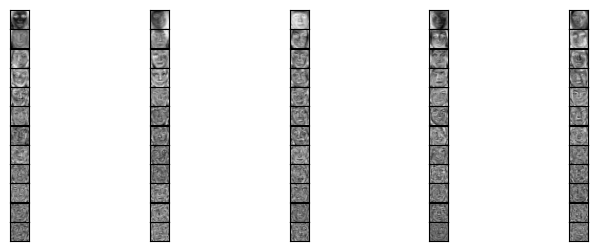

In [17]:
# Draw some of the eigen faces. To draw all change the subplot argument (p//5,5) to (p//x,x) (where p is a perfectly divisible by x)
fig, axes = plt.subplots(p//5,5,figsize=(9,3),
subplot_kw={'xticks':[], 'yticks':[]},
gridspec_kw=dict(hspace=0.01, wspace=0.01))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(100,100),cmap="gray")
plt.show()

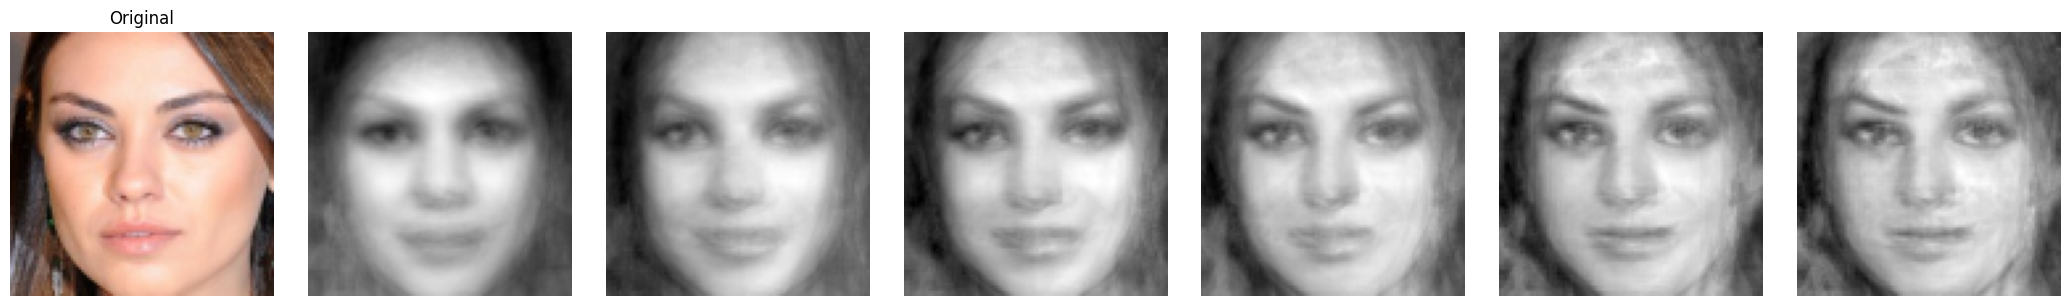

In [18]:
# Show reconstruction of a target face
# NOTE: Max principal components used is determined by n_components, so even if ks goes to 60 the function will only use n_components for the rconstruction.
pca.show_reconstruction_progression(
    test_X,
    image_index=30,
    ks=[1, 5, 10, 20, 40, 60] # how many principal components to use. 
)

### 1.2.2. Feature Space Plots

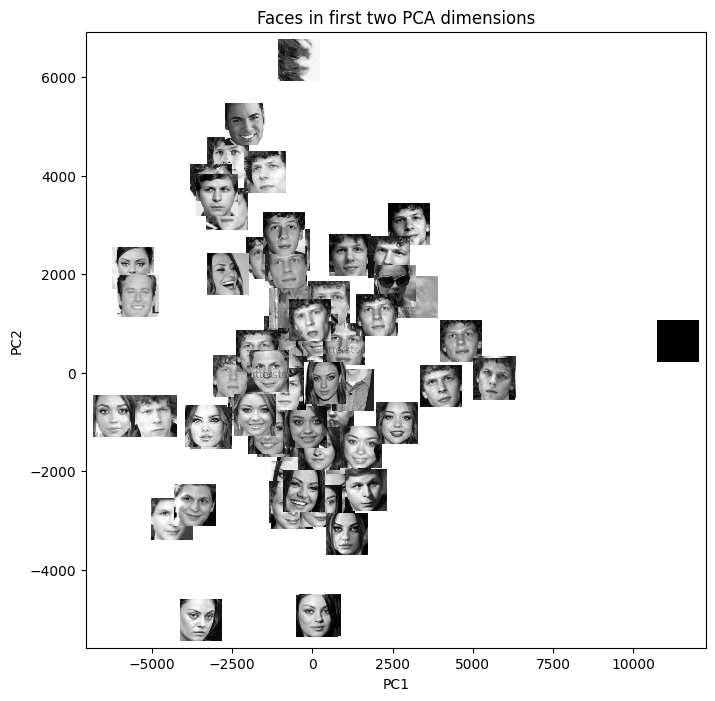

In [19]:
# Plot training features in the subspace contructed using first 2 components
pca.plot_faces_in_pca_space_with_extractor(train_X, zoom=0.3, max_points=80)

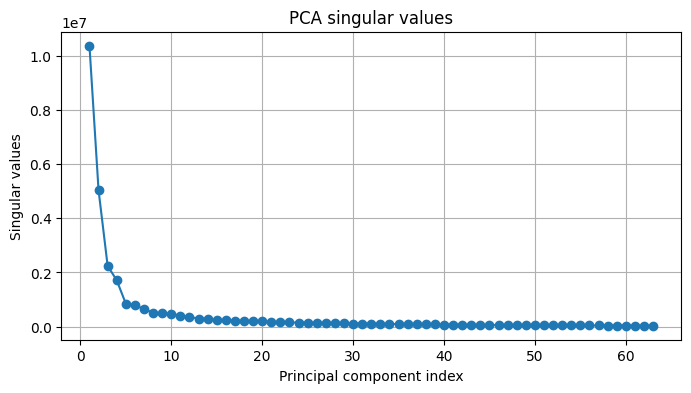

In [20]:
# Singular value plot to jugde the importance of each components, 
# clearly components 40 to 60 are not very much useful in contributing to the variance of the dataset and hence can be easily removed.
pca.plot_pca_eigenvalues()

### 1.2.3. Discussion
Most of the discussion is already present in the functions as commentsm especially the 'fit' function of class PCAFeatureExtractor. Below we have shown the importance of mean substraction step.

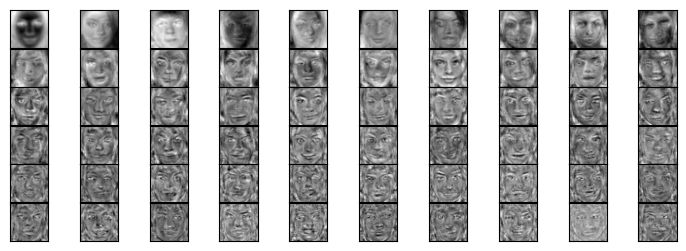

In [21]:
# Importance of mean

# Copy the training data to avoid manipulating the original data
exp_train = np.copy(train_X)

# Create an object to extract all possible principal components
pca_no_mean     = PCAFeatureExtractor(n_components=None)
train_Z_no_mean = pca_no_mean.fit(exp_train, comp_mean=False)                # Learn the components

# Draw some of the eigen faces. To draw all change the subplot argument (p//5,5) to (p//x,x) (where p is a perfectly divisible by x)
fig, axes = plt.subplots(p//10,10,figsize=(9,3),
subplot_kw={'xticks':[], 'yticks':[]},
gridspec_kw=dict(hspace=0.01, wspace=0.01))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca_no_mean.components_[i].reshape(100,100),cmap="gray")
plt.show()

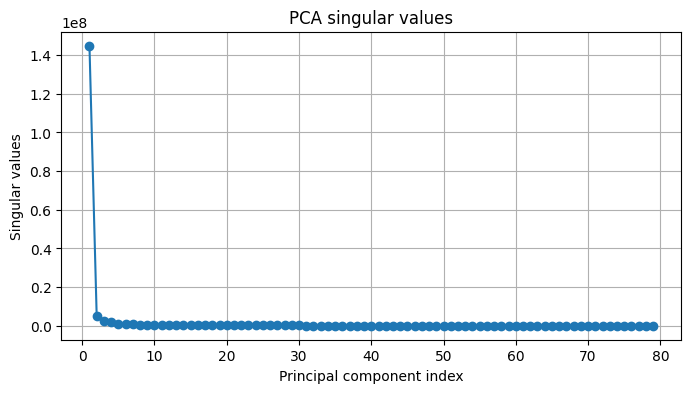

Chosen p with mean substracted = 26
Chosen p without mean substracted = 2


In [ ]:
# Comparing the below plot with mean substracted it is clear how the first few components is affected by the mean and hence misleads in terms of the singular values.
pca_no_mean.plot_pca_eigenvalues()

# The above point is also clearly observed here when choosing the right number of components. For the same dataset, 
# without mean says only the first two components are enough is to cover 90% of variance whereas actually we require 26 components for it.
p_mean, cumulative_var_mean = pca_all.choose_p_by_variance(threshold=0.90)
print("Chosen p with mean substracted =", p_mean)

p_no_mean, cumulative_var_no_mean = pca_no_mean.choose_p_by_variance(threshold=0.90)
print("Chosen p without mean substracted =", p_no_mean)

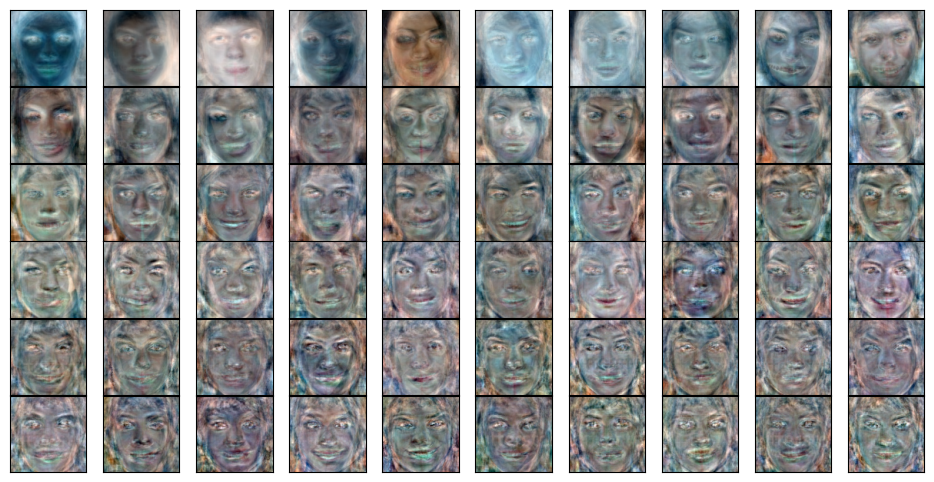

In [23]:
# Using all colours. One idea could be to utilize all the channels of the image to achieve better results, for this we extended the current grayscale image to use 
# all channels as [R, G, B]

# Copy the training data to avoid manipulating the original data
exp_train_2 = np.copy(train_X)

# Create an object to extract all possible principal components
pca_RGB     = PCAFeatureExtractor(n_components=None)
train_Z_RGB = pca_RGB.fit(exp_train_2, use_RGB=True)                # Learn the components

# Draw some of the eigen faces as RGB images. To draw all change the subplot argument (p//5,5) to (p//x,x) (where p is a perfectly divisible by x)
fig, axes = plt.subplots(p//10, 10, figsize=(12, 6),
                         subplot_kw={'xticks': [], 'yticks': []},
                         gridspec_kw=dict(hspace=0.01, wspace=0.01))

# The eigen faces shows a clear difference in color pattern(black at the top corners and skin color in the middle), which could be more useful when working with the classifier 
# however, since we are always working with face the added information related to the colors might not come handy as it is consistent across all the faces.
H, W = 100, 100
D = H * W
for i, ax in enumerate(axes.flat):
    eig_vec = pca_RGB.components_[i]

    r = eig_vec[0:D].reshape(H, W)
    b = eig_vec[D:2*D].reshape(H, W)
    g = eig_vec[2*D:3*D].reshape(H, W)

    eig = np.stack([r, g, b], axis=-1)   # convert back to RGB order

    eig_disp = (eig - eig.min()) / (eig.max() - eig.min() + 1e-8)
    ax.imshow(eig_disp)

plt.show()

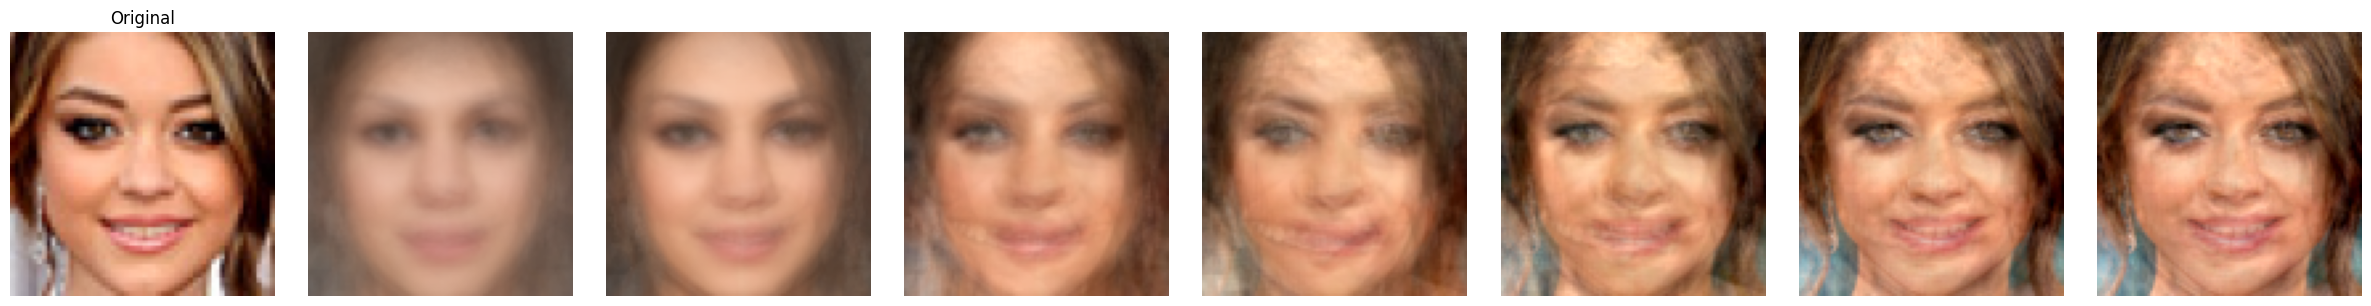

In [24]:
# Facial reconstruction uisng the RGB components.
pca_RGB.show_reconstruction_progression(
    test_X,
    image_index=7,
    ks=[1, 5, 10, 20, 40, 60, 80] # how many principal components to use. 
)

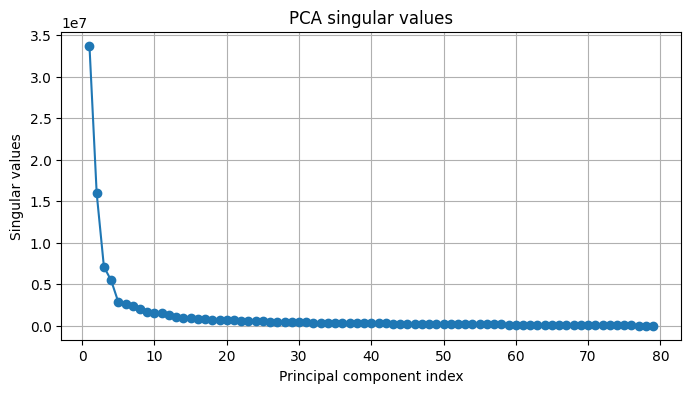

Chosen p without RGB substracted = 26
Chosen p with RGB substracted = 28


In [ ]:
# The singular values seems to be following the same trend as gray scale further supporting the claim that adding additional colors provides no improvement.
pca_RGB.plot_pca_eigenvalues()

# The above point is also clearly observed here when choosing the right number of components. For the same dataset, 
# with RGB says 28 components are needed is to cover 90% of variance whereas without it we require only 26 components.
p_mean, cumulative_var_mean = pca_all.choose_p_by_variance(threshold=0.90)
print("Chosen p without RGB substracted =", p_mean)

p_RGB, cumulative_var_no_mean = pca_RGB.choose_p_by_variance(threshold=0.90)
print("Chosen p with RGB substracted =", p_RGB)

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [26]:
from sklearn.metrics import accuracy_score

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [27]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [28]:
class FavoriteClassificationModel:
    """TODO: this classifier is under construction."""
    
    def fit(self, X, y):
        raise NotImplmentedError
        
    def predict(self, X):
        raise NotImplmentedError

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [29]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [30]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

'The performance on the training set is 0.26. This however, does not tell us much about the actual performance (generalisability).'

In [31]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [32]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

,class
id,
0,1
1,2
2,1
3,1
4,1
...,...
1811,1
1812,2
1813,2


In [33]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
